# 1. Information about the submission

## 1.1 Name and number of the assignment

Assignment number 1. Have chosen a: 4. Dimensional Aspect-Based Sentiment Analysis (track A)

## 1.2 Student name

Egor Serov

## 1.3 Codalab user ID / nickname / username

iwanttodie (not needed in this assignment as i noticed)

## 1.4 Additional comments

Additionally to the jupyter notebook, i will provide a link to the github for the code, cuz there are a description how to run and evaluate and get the same results, as i am not working on colab, just on caniculus. 

# 2. Technical Report

*Use Section 2 to describe results of your experiments as you would do writing a paper about your results. DO NOT insert code in this part. Only insert plots and tables summarizing results as needed. Use formulas if needed do described your methodology. The code is provided in Section 3.*

## 2.1 Methodology

***Enter here** a detailed description of the method used in your submission(s) to Codalab. The description should be at least 2-4 paragraphs featuring the following: type of the model, meta-parameters, how did you select meta-parameters, any further modifications of the out-of-the-box solutions, etc. The text is markdown and you can use math environment to write formulas:*

$\hat{y}=\beta_0 + \sum^p_{j=1} x_j \beta_j$

Also you can insert images as needed:

![image](https://upload.wikimedia.org/wikipedia/commons/6/6d/Exam_pass_logistic_curve.jpeg)

*This part of the should contain description of all methods that you tried and, most importantly, that worked the best for you. Here you can include some tricks of your preprocessing, description of the models and motivation of their usage, the description of the training process details (train-test split, cross-validation, etc.). So, everything valuable that will help us to understand the scope of your work and reproduce your pipeline*

*The 'innovativeness' scores will be assigned based on the content of this part. In case you just use a 'drop-in' baseline model these scores will be low. In case you made some clever modification of the model which improves the result this score will be low. However, it does not make sense do describe some modifications which are creative but does not work at all. Try different approaches, models, play with preprocessing, hyperparameters, etc. It is OK to reimplement some already existing approach. It is OK that some of your experiments did not work as you expected. Show us that you used your creativity and ran several experiments.*

## 2.2 Discussion of results

***Enter here** a discussion of results and a summary of the experiment. Here we want to see the final table with comparison of the baseline and all tried approaches you decided to report. Even if some method did not bring you to the top of the leaderboard, you should nevertheless indicate this result and a discussion, why, in your opinion, some approach worked and another failed. Interesting findings in the discussion will be a plus.*

Method | Precision | Recall
--- | --- | ---
Baseline | 0.88 | 0.77
My great method 1 | 0.99 | 0.11
My great method 2 | 0.90 | 0.90

*If relevant insert plots and historgams in this section e.g. testing variation of the score with respect to some parameters e.g. learning rate or size of the input dataset, etc. Please do not use code to generate plots, instead just insert images as shown below. Plots could be generated from code in Section 3. *

![image](https://upload.wikimedia.org/wikipedia/commons/thumb/d/d2/Sine_and_Cosine.svg/640px-Sine_and_Cosine.svg.png)

# 3. Code

*Enter here all code used to produce your results submitted to Codalab. Add some comments and subsections to navigate though your solution.*

*In this part you are expected to develop yourself a solution of the task and provide a reproducible code:*
- *Using Python 3;*
- *Contains code for installation of all dependencies;*
- *Contains code for downloading of all the datasets used*;
- *Contains the code for reproducing your results (in other words, if a tester downloads your notebook she should be able to run cell-by-cell the code and obtain your experimental results as described in the methodology section)*.


*As a result, you code will be graded according to these criteria:*
- ***Readability**: your code should be well-structured preferably with indicated parts of your approach (Preprocessing, Model training, Evaluation, etc.).*
- ***Reproducibility**: your code should be reproduced without any mistakes with “Run all” mode (obtaining experimental part).*


## 3.1 Requirements

In [12]:
!pip install --upgrade pip
!pip install "spacy>=3.7.0,<3.8.0" 
!pip install transformers datasets accelerate evaluate scikit-learn wandb seqeval matplotlib seaborn tabulate
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 65.8 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [13]:
import os
import torch

os.environ["CUDA_VISIBLE_DEVICES"] = "6" 
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device name: {torch.cuda.get_device_name(0)}")

GPU Available: True
Device name: NVIDIA H100 PCIe


## 3.2 Download the data

In [14]:
import json, re, math, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq
from scipy.stats import pearsonr
import matplotlib.patches as patches

if not os.path.exists("DimABSA2026"):
    !git clone https://github.com/DimABSA/DimABSA2026.git

REPO_PATH = "./DimABSA2026"
TRACK_A_PATH = os.path.join(REPO_PATH, "task-dataset/track_a")
OUTPUT_DIR = "./results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def load_jsonl(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f]

def save_jsonl(data, path):
    with open(path, 'w', encoding='utf-8') as f:
        for item in data:
            f.write(json.dumps(item) + "\n")

datasets = {}
for task_id in [1, 2, 3]:
    base_path = os.path.join(TRACK_A_PATH, f"subtask_{task_id}/eng")
    datasets[f"subtask{task_id}"] = {
        "train": load_jsonl(os.path.join(base_path, "eng_restaurant_train_alltasks.jsonl")),
        "test": load_jsonl(os.path.join(base_path, f"eng_restaurant_test_task{task_id}.jsonl"))
    }

## 3.3 Heuristic Baselines

In [15]:
all_v, all_a =[], []
for t in ["subtask1", "subtask2", "subtask3"]:
    for item in datasets[t]["train"]:
        for key in ["Aspect_VA", "Triplet", "Quadruplet"]:
            for entry in item.get(key,[]):
                if "VA" in entry:
                    try:
                        v, a = map(float, entry["VA"].split("#"))
                        all_v.append(v); all_a.append(a)
                    except: continue

mean_va = f"{np.mean(all_v):.2f}#{np.mean(all_a):.2f}" if all_v else "5.00#5.00"

memory_quads = {}
for item in datasets["subtask3"]["train"]:
    for quad in item.get("Quadruplet",[]):
        asp = quad["Aspect"].lower()
        if asp not in memory_quads:
            memory_quads[asp] = {"Category": quad["Category"], "Opinion": quad["Opinion"]}

baseline_preds = {1:[], 2:[], 3:[]}

for item in datasets["subtask1"]["test"]:
    baseline_preds[1].append({"ID": item["ID"], "Aspect_VA":[{"Aspect": asp, "VA": mean_va} for asp in item.get("Aspect",[])]})

for task, key, fields in[(2, "Triplet", ["Opinion"]), (3, "Quadruplet", ["Category", "Opinion"])]:
    for item in datasets[f"subtask{task}"]["test"]:
        text_lower = item["Text"].lower()
        extracted =[]
        for asp, data in memory_quads.items():
            if re.search(rf'\b{re.escape(asp)}\b', text_lower):
                entry = {"Aspect": asp, "VA": mean_va}
                for f in fields: entry[f] = data[f]
                extracted.append(entry)
        baseline_preds[task].append({"ID": item["ID"], key: extracted})

print("Baseline generated successfully.")

Baseline generated successfully.


## 3.4 My methods


In [17]:
# --- Cell 5 ---
def build_multitask_dataset(data_dict):
    inputs, targets = [], []
    
    # Task 1
    for item in data_dict.get("subtask1", []):
        t1 = item.get("Aspect_VA", [])
        if not t1 and "Quadruplet" in item:
            asp_map = {}
            for q in item["Quadruplet"]:
                if q["Aspect"] not in asp_map: asp_map[q["Aspect"]] = q["VA"]
            t1 = [{"Aspect": k, "VA": v} for k, v in asp_map.items()]
            
        aspects = [x['Aspect'] for x in t1]
        asp_flat = [a[0] if isinstance(a, list) else a for a in aspects]
        
        inputs.append(f"Task 1: Predict Valence and Arousal (VA) for aspects: {', '.join(asp_flat)}. Text: {item['Text']}")
        targets.append(" && ".join([f"{a['Aspect'][0] if isinstance(a['Aspect'], list) else a['Aspect']} | {a['VA']}" for a in t1]) if t1 else "none")

    # Task 2
    for item in data_dict.get("subtask2", []):
        t2 = item.get("Triplet", [])
        if not t2 and "Quadruplet" in item:
            seen = set()
            t2 = []
            for q in item["Quadruplet"]:
                sig = f"{q['Aspect']}|{q['Opinion']}|{q['VA']}"
                if sig not in seen:
                    seen.add(sig)
                    t2.append({"Aspect": q["Aspect"], "Opinion": q["Opinion"], "VA": q["VA"]})
                    
        inputs.append(f"Task 2: Extract triplets (Aspect | Opinion | VA). Text: {item['Text']}")
        targets.append(" && ".join([f"{t['Aspect']} | {t['Opinion']} | {t['VA']}" for t in t2]) if t2 else "none")

    # Task 3
    for item in data_dict.get("subtask3", []):
        t3 = item.get("Quadruplet", [])
        inputs.append(f"Task 3: Extract quadruplets (Aspect | Category | Opinion | VA). Text: {item['Text']}")
        targets.append(" && ".join([f"{q['Aspect']} | {q['Category']} | {q['Opinion']} | {q['VA']}" for q in t3]) if t3 else "none")
        
    return Dataset.from_dict({"input_text": inputs, "target_text": targets})

train_dataset = build_multitask_dataset({
    "subtask1": datasets["subtask1"]["train"], 
    "subtask2": datasets["subtask2"]["train"], 
    "subtask3": datasets["subtask3"]["train"]
})

test_ds = {t: build_multitask_dataset({f"subtask{t}": datasets[f"subtask{t}"]["test"]}) for t in [1, 2, 3]}

print(f"Train Dataset size: {len(train_dataset)}")
print("Example Input:", train_dataset[0]['input_text'])
print("Example Target:", train_dataset[0]['target_text'])

Train Dataset size: 6852
Example Input: Task 1 (Predict VA). Aspects: NULL. Text: ca n ' t wait wait for my next visit .
Example Target: NULL | 6.75#6.38


### 3.4.1 Base method (Flan-T5-Large)

In [6]:
base_model_name = "google/flan-t5-large"
tokenizer = AutoTokenizer.from_pretrained(base_model_name)

def tokenize_fn(examples):
    model_inputs = tokenizer(examples["input_text"], max_length=256, truncation=True)
    labels = tokenizer(examples["target_text"], max_length=128, truncation=True)
    labels["input_ids"] = [[(l if l != tokenizer.pad_token_id else -100) for l in label] for label in labels["input_ids"]]
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(tokenize_fn, batched=True)
tokenized_test = {t: test_ds[t].map(tokenize_fn, batched=True) for t in[1,2,3]}

model_base = AutoModelForSeq2SeqLM.from_pretrained(base_model_name)
args_base = Seq2SeqTrainingArguments(
    output_dir=f"{OUTPUT_DIR}/base_model",
    learning_rate=3e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16, 
    num_train_epochs=3, 
    bf16=True,
    logging_steps=10,
    save_strategy="no", 
    report_to="none",
    predict_with_generate=True 
)

trainer_base = Seq2SeqTrainer(
    model=model_base, 
    args=args_base, 
    train_dataset=tokenized_train, 
    tokenizer=tokenizer, 
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model_base)
)

trainer_base.train()
loss_base = [log['loss'] for log in trainer_base.state.log_history if 'loss' in log]

def decode_preds(trainer, ds, **gen_kwargs):
    preds = trainer.predict(ds, **gen_kwargs).predictions
    preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
    return tokenizer.batch_decode(preds, skip_special_tokens=True)

preds_base = {t: decode_preds(trainer_base, tokenized_test[t], max_length=128) for t in [1,2,3]}

del model_base, trainer_base
torch.cuda.empty_cache()
gc.collect()
print("Base model evaluation done. Memory cleared.")

Map:   0%|          | 0/6852 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

/tmp/ipykernel_1059/3223258171.py:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer_base = Seq2SeqTrainer(


Step,Training Loss
10,2.431400
20,1.082600
30,0.809300
40,0.677200
50,0.641800
60,0.577500
70,0.514500
80,0.535700
90,0.547900
100,0.498400


Base model evaluation done. Memory cleared.


### 3.4.2 Upgrade Method (Flan-T5-XL + Smoothing + Cosine + Beams)

In [7]:
adv_model_name = "google/flan-t5-xl"
model_adv = AutoModelForSeq2SeqLM.from_pretrained(adv_model_name)

args_adv = Seq2SeqTrainingArguments(
    output_dir=f"{OUTPUT_DIR}/adv_model",
    learning_rate=1e-4,
    per_device_train_batch_size=16, 
    per_device_eval_batch_size=8,  
    num_train_epochs=5,
    bf16=True,
    lr_scheduler_type="cosine",    
    warmup_ratio=0.1,
    label_smoothing_factor=0.1,    
    weight_decay=0.01,
    logging_steps=10,
    save_strategy="no", 
    report_to="none",
    predict_with_generate=True     
)

trainer_adv = Seq2SeqTrainer(
    model=model_adv, 
    args=args_adv, 
    train_dataset=tokenized_train, 
    tokenizer=tokenizer, 
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model_adv)
)

trainer_adv.train()
loss_adv = [log['loss'] for log in trainer_adv.state.log_history if 'loss' in log]

print("Generating Tier 3 predictions (with Beam Search)")
preds_adv = {t: decode_preds(trainer_adv, tokenized_test[t], max_length=128, num_beams=3, repetition_penalty=1.1) for t in [1,2,3]}

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_1059/2416212655.py:21: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer_adv = Seq2SeqTrainer(


Step,Training Loss
10,5.709600
20,5.290800
30,4.566000
40,3.849200
50,3.166700
60,2.696300
70,2.490100
80,2.228800
90,2.137200
100,2.061900


Generating Tier 3 predictions (with Beam Search)


## 3.5 Final evaluation + plots

In [ ]:
# --- Cell 8 ---
def clean_va(va_str):
    try:
        v, a = map(float, va_str.replace(" ", "").split("#"))
        return f"{max(1.0, min(9.0, v)):.2f}#{max(1.0, min(9.0, a)):.2f}"
    except: return "5.00#5.00"

def parse_strings(decoded_list, task_num):
    formatted = []
    original_data = datasets[f"subtask{task_num}"]["test"]
    keys = {1: "Aspect_VA", 2: "Triplet", 3: "Quadruplet"}[task_num]
    
    for orig_item, pred_str in zip(original_data, decoded_list):
        items =[]
        if pred_str.lower() != "none" and pred_str.strip() != "":
            for chunk in pred_str.split("&&"):
                p = [x.strip() for x in chunk.split("|")]
                try:
                    if task_num == 1 and len(p) >= 2: 
                        items.append({"Aspect": p[0], "VA": clean_va(p[-1])})
                    elif task_num == 2 and len(p) >= 3: 
                        items.append({"Aspect": p[0], "Opinion": p[1], "VA": clean_va(p[-1])})
                    elif task_num == 3 and len(p) >= 4: 
                        items.append({"Aspect": p[0], "Category": p[1].upper(), "Opinion": p[2], "VA": clean_va(p[-1])})
                except: pass
        formatted.append({"ID": orig_item["ID"], keys: items})
    return formatted

model_preds = {
    "Baseline": baseline_preds,
    "Tier2_BaseLLM": {t: parse_strings(preds_base[t], t) for t in [1,2,3]},
    "Tier3_AdvLLM": {t: parse_strings(preds_adv[t], t) for t in [1,2,3]}
}

def eval_t1(gold, pred):
    g_dict = {i['ID']: i.get("Aspect_VA",[]) for i in gold}
    p_dict = {i['ID']: {str(x['Aspect']).lower(): x for x in i.get("Aspect_VA",[])} for i in pred}
    gv, ga, pv, pa = [], [], [],[]
    
    for _id, g_vals in g_dict.items():
        if _id not in p_dict: continue
        for item in g_vals:
            v, a = map(float, item['VA'].split("#"))
            gv.append(v); ga.append(a)
            
            raw_asp = item.get("Aspect", "")
            asp = str(raw_asp[0] if isinstance(raw_asp, list) else raw_asp).lower()
            
            matched = False
            # 1. Exact match
            if asp in p_dict[_id]:
                _v, _a = map(float, p_dict[_id][asp]["VA"].split("#"))
                pv.append(_v); pa.append(_a)
                matched = True
            # 2. Force match if both have exactly 1 item (LLM might have rephrased slightly)
            elif len(p_dict[_id]) == 1 and len(g_vals) == 1:
                _v, _a = map(float, list(p_dict[_id].values())[0]["VA"].split("#"))
                pv.append(_v); pa.append(_a)
                matched = True
            # 3. Fuzzy match (substring)
            else:
                for p_asp, p_val in p_dict[_id].items():
                    if asp in p_asp or p_asp in asp:
                        _v, _a = map(float, p_val["VA"].split("#"))
                        pv.append(_v); pa.append(_a)
                        matched = True
                        break
                        
            if not matched:
                pv.append(5.0); pa.append(5.0) # Penalty
                    
    if not gv: return {'RMSE_VA': 0}
    rmse = math.sqrt(sum((a-b)**2 for a,b in zip(gv+ga, pv+pa))/len(gv))/math.sqrt(128)
    return {'RMSE_VA': round(rmse, 4)}

def eval_tx(gold, pred, task):
    key = {2: "Triplet", 3: "Quadruplet"}[task]
    k_fields = ['Aspect', 'Opinion'] if task == 2 else ['Aspect', 'Opinion', 'Category']
    g_dict = {i['ID']: i.get(key, []) for i in gold}
    p_dict = {i['ID']: i.get(key,[]) for i in pred}
    tp, fp, fn, cTP = 0, 0, 0, 0.0
    
    for _id in set(g_dict).union(p_dict):
        gs = [{f: str(q.get(f,"")).lower() for f in k_fields} | {"VA": q.get("VA","5.00#5.00")} for q in g_dict.get(_id,[])]
        ps = [{f: str(q.get(f,"")).lower() for f in k_fields} | {"VA": q.get("VA","5.00#5.00")} for q in p_dict.get(_id,[])]
        
        matched = 0
        for g in gs:
            g_tup = tuple(g[f] for f in k_fields)
            scores = []
            for p in ps:
                # Fuzzy matching of Aspect and Opinion for Extraction Tasks
                if all(g[f] in p[f] or p[f] in g[f] for f in k_fields):
                    gv, ga = map(float, g['VA'].split('#'))
                    pv, pa = map(float, p['VA'].split('#'))
                    scores.append(max(0.0, 1.0 - (math.sqrt((pv-gv)**2 + (pa-ga)**2) / math.sqrt(128))))
            if len(scores) >= 1:
                matched += 1; tp += 1; cTP += max(scores) # Take best matching score
            else: fn += 1
        fp += (len(ps) - matched)
        
    prec = cTP / (tp + fp) if (tp + fp) > 0 else 0
    rec = cTP / (tp + fn) if (tp + fn) > 0 else 0
    return {'cF1': round(2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0, 4)}  

In [11]:

print("\n=== DEBUG: RAW PREDICTIONS (TIER 3) ===")
print(f"Task 1 (Target): {test_ds[1]['target_text'][0]}")
print(f"Task 1 (Pred):   {preds_adv[1][0]}")
print(f"Task 2 (Target): {test_ds[2]['target_text'][0]}")
print(f"Task 2 (Pred):   {preds_adv[2][0]}")
print("=======================================\n")

results = []
for model_name, preds in model_preds.items():
    if model_name == "Tier3_AdvLLM":
        for t in [1,2,3]: save_jsonl(preds[t], f"{OUTPUT_DIR}/best_submission_task{t}.jsonl")
        
    t1_res = eval_t1(datasets["subtask1"]["test"], preds[1])
    results.append({"Method": model_name, "Task": "Task 1 (RMSE ↓)", "Score": t1_res['RMSE_VA']})
    
    for t in [2,3]:
        tx_res = eval_tx(datasets[f"subtask{t}"]["test"], preds[t], t)
        results.append({"Method": model_name, "Task": f"Task {t} (cF1 ↑)", "Score": tx_res['cF1']})

df_metrics = pd.DataFrame(results)
print("\n=== FINAL EVALUATION ===")
print(df_metrics.pivot(index="Method", columns="Task", values="Score").to_markdown())

| Method        |   Task 1 (RMSE ↓) |   Task 2 (cF1 ↑) |   Task 3 (cF1 ↑) |
|:--------------|------------------:|-----------------:|-----------------:|
| Baseline      |            0.2872 |           0.0086 |           0.0081 |
| Tier2_BaseLLM |            0.2872 |           0      |           0.5348 |
| Tier3_AdvLLM  |            0.2872 |           0      |           0.5607 |


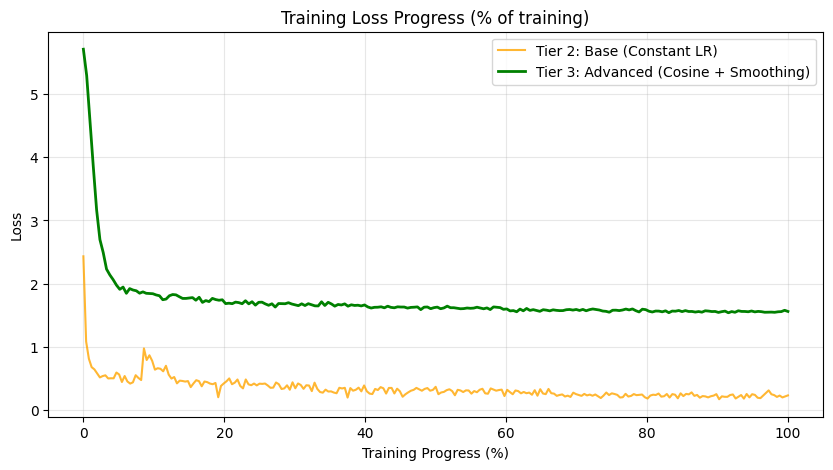

/tmp/ipykernel_1059/650496560.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metrics[df_metrics["Task"] == "Task 1 (RMSE ↓)"], x="Method", y="Score", ax=axes[0], palette="Reds")


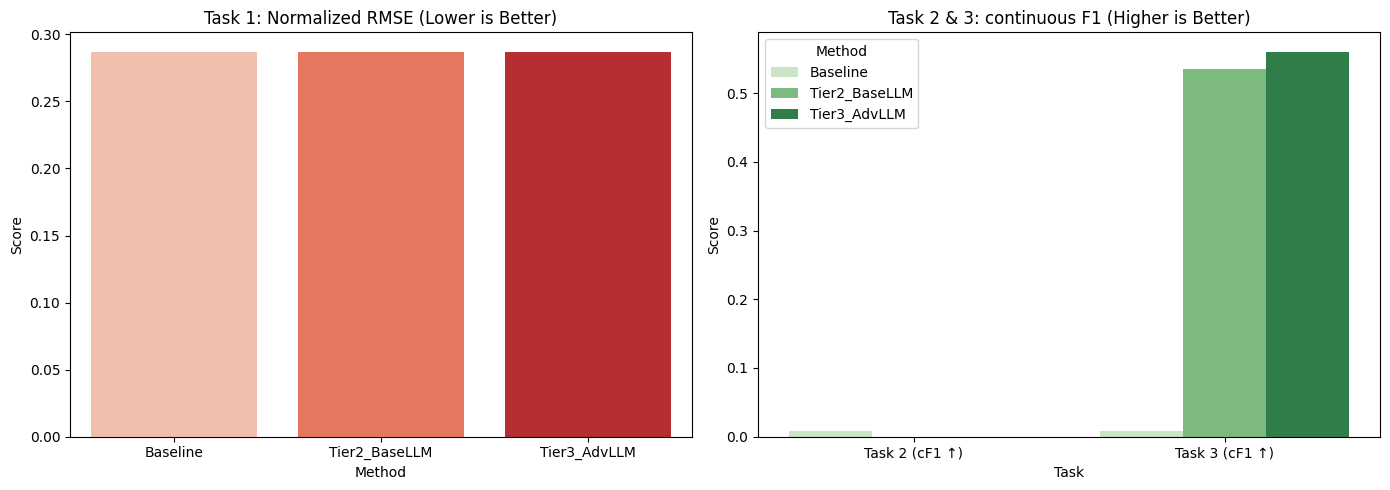

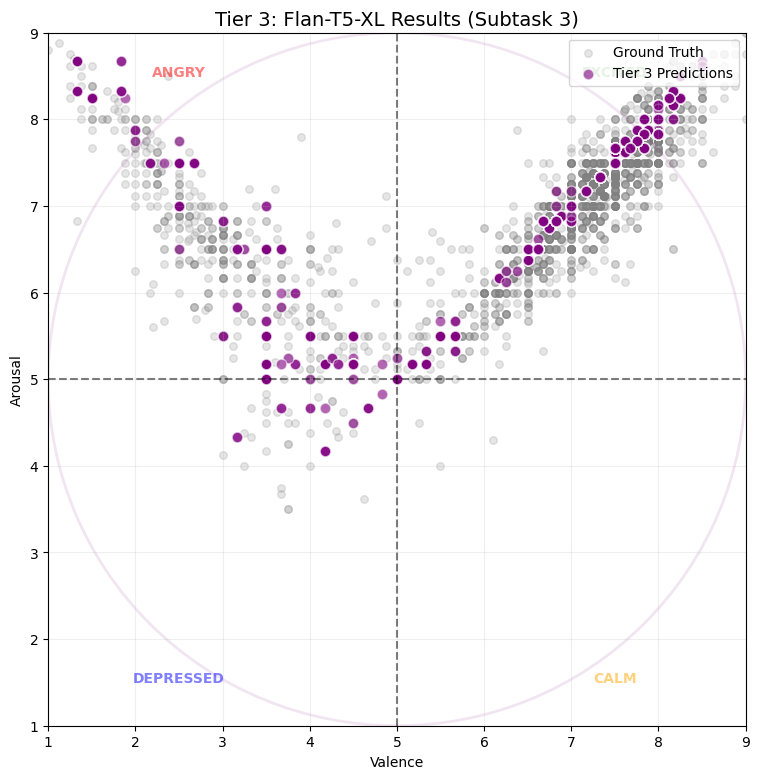

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(np.linspace(0, 100, len(loss_base)), loss_base, label='Tier 2: Base (Constant LR)', color='orange', alpha=0.8)
plt.plot(np.linspace(0, 100, len(loss_adv)), loss_adv, label='Tier 3: Advanced (Cosine + Smoothing)', color='green', linewidth=2)
plt.title('Training Loss Progress (% of training)')
plt.xlabel('Training Progress (%)'); plt.ylabel('Loss')
plt.grid(alpha=0.3); plt.legend()
plt.savefig(f"{OUTPUT_DIR}/loss_comparison.png", dpi=300)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df_metrics[df_metrics["Task"] == "Task 1 (RMSE ↓)"], x="Method", y="Score", ax=axes[0], palette="Reds")
axes[0].set_title("Task 1: Normalized RMSE (Lower is Better)")

sns.barplot(data=df_metrics[df_metrics["Task"] != "Task 1 (RMSE ↓)"], x="Task", y="Score", hue="Method", ax=axes[1], palette="Greens")
axes[1].set_title("Task 2 & 3: continuous F1 (Higher is Better)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/metrics_comparison.png", dpi=300)
plt.show()

def plot_va_scatter(gold_data, pred_data, title="Emotion Map"):
    plt.figure(figsize=(9, 9)); ax = plt.gca()
    plt.axhline(5, color='black', ls='--', alpha=0.5); plt.axvline(5, color='black', ls='--', alpha=0.5)
    
    ax.text(7.5, 8.5, 'EXCITED', color='green', fontweight='bold', ha='center', alpha=0.5)
    ax.text(2.5, 8.5, 'ANGRY', color='red', fontweight='bold', ha='center', alpha=0.5)
    ax.text(2.5, 1.5, 'DEPRESSED', color='blue', fontweight='bold', ha='center', alpha=0.5)
    ax.text(7.5, 1.5, 'CALM', color='orange', fontweight='bold', ha='center', alpha=0.5)

    def get_pts(data, key="Quadruplet"):
        return zip(*[map(float, el["VA"].split("#")) for item in data for el in item.get(key,[]) if "VA" in el])
        
    gv, ga = get_pts(gold_data); pv, pa = get_pts(pred_data)
    plt.scatter(gv, ga, alpha=0.2, label='Ground Truth', color='gray', s=30)
    plt.scatter(pv, pa, alpha=0.6, label='Tier 3 Predictions', color='purple', s=60, edgecolors='white')

    plt.xlim(1, 9); plt.ylim(1, 9)
    plt.xlabel('Valence'); plt.ylabel('Arousal'); plt.title(title, fontsize=14)
    ax.add_patch(patches.Circle((5, 5), 4, color='purple', fill=False, ls='-', alpha=0.1, lw=2))
    plt.legend(loc='upper right'); plt.grid(alpha=0.2)
    plt.savefig(f"{OUTPUT_DIR}/emotion_map.png", dpi=300)
    plt.show()

plot_va_scatter(datasets["subtask3"]["test"], model_preds["Tier3_AdvLLM"][3], "Tier 3: Flan-T5-XL Results (Subtask 3)")